# Alignment Integration

Temporal alignment between source speech timing and target-language TTS audio.
This is the hard problem: a 3-second English phrase might take 5 seconds in Spanish.

Covers segment metrics, fallback policy, and global timeline optimization.

## Setup

In [1]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

IMAGES_DIR = Path.cwd() / "images"
IMAGES_DIR.mkdir(exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"IMAGES_DIR:   {IMAGES_DIR}")

PROJECT_ROOT: /home/zuhair/Desktop/foreign-whispers
IMAGES_DIR:   /home/zuhair/Desktop/foreign-whispers/notebooks/alignment_integration/images


## Load Cached Transcripts

Load from `pipeline_data` (no API call needed).

In [2]:
en_dir = PROJECT_ROOT / "pipeline_data" / "api" / "transcriptions" / "whisper"
es_dir = PROJECT_ROOT / "pipeline_data" / "api" / "translations" / "argos"

en_files = sorted(en_dir.glob("*.json"))
es_files = sorted(es_dir.glob("*.json"))

assert en_files, f"No EN transcripts found in {en_dir}"
assert es_files, f"No ES translations found in {es_dir}"

en_path = en_files[0]
es_path = es_files[0]

with open(en_path) as f:
    en_transcript = json.load(f)
with open(es_path) as f:
    es_transcript = json.load(f)

print(f"EN transcript: {en_path.name}  ({len(en_transcript.get('segments', []))} segments)")
print(f"ES transcript: {es_path.name}  ({len(es_transcript.get('segments', []))} segments)")

EN transcript: Strait of Hormuz disruption threatens to shake global economy.json  (170 segments)
ES transcript: Strait of Hormuz disruption threatens to shake global economy.json  (170 segments)


## Segment Timing Metrics

Compute predicted stretch factor and overflow for each segment.

The syllable-based duration heuristic estimates TTS output length at ~4.5 syllables/second
for Romance languages (~15 chars/s). For each segment we compare the predicted TTS duration
against the source-language time window to get `predicted_stretch` (1.0 = perfect fit,
1.3 = 30% too long).

**Notice what happens:** many segments have stretch factors well above 1.0. The translator
doesn't know about the timing budget — it just rewrites text without considering how long
it takes to speak. This is the core problem you'll address in the tasks below.

In [3]:
from foreign_whispers import (
    AlignAction, AlignedSegment, SegmentMetrics,
    compute_segment_metrics, decide_action,
)

all_metrics = compute_segment_metrics(en_transcript, es_transcript)
bad = [m for m in all_metrics if m.predicted_stretch > 1.5]

print(f"Total segments : {len(all_metrics)}")
print(f"Stretch > 1.5x : {len(bad)}  ({100*len(bad)/max(len(all_metrics),1):.0f}%)")
print("\nWorst 5:")
for m in sorted(bad, key=lambda x: -x.predicted_stretch)[:5]:
    print(f"  seg {m.index:3d}  stretch={m.predicted_stretch:.2f}x  overflow={m.overflow_s:.1f}s")
    print(f"    EN: {m.source_text[:55]}")
    print(f"    ES: {m.translated_text[:55]}")

Total segments : 170
Stretch > 1.5x : 0  (0%)

Worst 5:


## Visualize Stretch Distribution

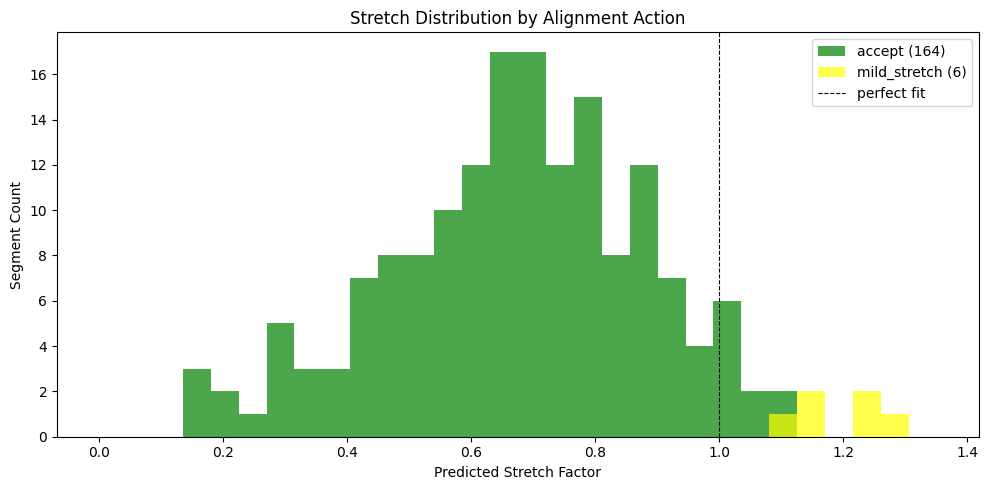

Saved to /home/zuhair/Desktop/foreign-whispers/notebooks/alignment_integration/images/stretch_distribution.png


In [4]:
import matplotlib.pyplot as plt
import numpy as np

stretches = [m.predicted_stretch for m in all_metrics]
actions = [decide_action(m) for m in all_metrics]

color_map = {
    AlignAction.ACCEPT: "green",
    AlignAction.MILD_STRETCH: "yellow",
    AlignAction.GAP_SHIFT: "orange",
    AlignAction.REQUEST_SHORTER: "red",
    AlignAction.FAIL: "darkred",
}
colors = [color_map[a] for a in actions]

fig, ax = plt.subplots(figsize=(10, 5))

# Group by action for legend
for action in AlignAction:
    vals = [s for s, a in zip(stretches, actions) if a == action]
    if vals:
        ax.hist(vals, bins=30, alpha=0.7, color=color_map[action],
                label=f"{action.value} ({len(vals)})", range=(0, max(stretches) * 1.05))

ax.axvline(x=1.0, color="black", linestyle="--", linewidth=0.8, label="perfect fit")
ax.set_xlabel("Predicted Stretch Factor")
ax.set_ylabel("Segment Count")
ax.set_title("Stretch Distribution by Alignment Action")
ax.legend()
fig.tight_layout()
fig.savefig(IMAGES_DIR / "stretch_distribution.png", dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'stretch_distribution.png'}")

---

## Task 1: Improve TTS Duration Prediction

The stretch factors above rely on a crude heuristic: ~15 characters/second for Spanish. Look at the worst segments — the heuristic is often wrong because character count ignores syllable structure, pauses, and speaking rate.

**Goal:** Replace the heuristic with a better duration predictor and measure whether it reduces alignment errors.

**Approach:**
1. Collect ground-truth durations by running TTS on a sample of segments and measuring actual WAV duration
2. Compare predictors: character count, syllable count (use a Spanish syllabifier), and a simple regression model trained on (text features → actual TTS duration)
3. Plug your predictor into `compute_segment_metrics` by modifying the `predicted_tts_duration_s` calculation in `foreign_whispers/alignment.py`

**File to modify:** `foreign_whispers/alignment.py` — the `_estimate_duration` helper

**Evaluation:**
- Mean absolute duration error (predicted vs actual TTS output)
- Calibration: does the predictor work equally well for short and long utterances?
- Downstream: does the improved predictor change the action distribution (fewer `REQUEST_SHORTER` or `FAIL`)? Re-run the policy histogram below to check.

In [6]:
# Task 1: Baseline — measure how wrong the current heuristic is
# Compare predicted duration (chars/15) against actual TTS WAV durations

tts_root = PROJECT_ROOT / "pipeline_data" / "api" / "tts_audio" / "chatterbox"
align_files = sorted(tts_root.rglob("*.align.json"))

if align_files:
    report = json.loads(align_files[0].read_text())
    segments = report.get("segments", [])

    errors = []
    for seg in segments:
        predicted = seg["target_sec"]  # source window duration
        actual = seg.get("raw_duration_s", 0)
        if actual > 0:
            errors.append(abs(predicted - actual))

    if errors:
        print(f"Segments with TTS ground truth: {len(errors)}")
        print(f"Mean absolute error:  {sum(errors)/len(errors):.2f}s")
        print(f"Max error:            {max(errors):.2f}s")
        print(f"\nThis is the baseline to beat with a better predictor.")
        print(f"Modify _estimate_duration() in foreign_whispers/alignment.py")
    else:
        print("No raw_duration_s data — run the TTS pipeline first (tts_integration notebook)")
else:
    print("No alignment reports found — run the TTS pipeline first")

Segments with TTS ground truth: 170
Mean absolute error:  1.61s
Max error:            5.46s

This is the baseline to beat with a better predictor.
Modify _estimate_duration() in foreign_whispers/alignment.py


Segments with TTS ground truth: 170
Mean absolute error:  1.61s
Max error:            5.46s

This is the baseline to beat with a better predictor.
Modify _estimate_duration() in foreign_whispers/alignment.py


In [7]:
import json
from pathlib import Path
from foreign_whispers.alignment import _count_syllables

tts_root = PROJECT_ROOT / "pipeline_data" / "api" / "tts_audio" / "chatterbox"
align_files = sorted(tts_root.rglob("*.align.json"))
report = json.loads(align_files[0].read_text())
segments = report.get("segments", [])

rates = []
for seg in segments:
    actual = seg.get("raw_duration_s", 0)
    text = seg.get("text", "")
    if actual > 0 and text:
        syllables = _count_syllables(text)
        rates.append(syllables / actual)

print(f"Mean syllable rate: {sum(rates)/len(rates):.2f} syllables/sec")
print(f"Min: {min(rates):.2f}  Max: {max(rates):.2f}")

Mean syllable rate: 3.84 syllables/sec
Min: 1.59  Max: 5.41


In [9]:
from foreign_whispers.alignment import _estimate_duration

errors_old = []
errors_new = []

for seg in segments:
    actual = seg.get("raw_duration_s", 0)
    text = seg.get("text", "")
    if actual > 0 and text:
        predicted_old = len(text) / 15.0          # old chars heuristic
        predicted_new = _estimate_duration(text)   # our new predictor
        errors_old.append(abs(predicted_old - actual))
        errors_new.append(abs(predicted_new - actual))

print(f"Chars/15 MAE:       {sum(errors_old)/len(errors_old):.3f}s")
print(f"Pyphen+3.84 MAE:    {sum(errors_new)/len(errors_new):.3f}s")
print(f"Improvement:        {sum(errors_old)/len(errors_old) - sum(errors_new)/len(errors_new):.3f}s")

Chars/15 MAE:       0.767s
Pyphen+3.84 MAE:    0.383s
Improvement:        0.384s


## Alignment Fallback Policy

| Stretch Factor | Action            | Description                                |
|----------------|-------------------|--------------------------------------------|
| <= 1.1         | ACCEPT            | Fits naturally, no change needed           |
| 1.1 - 1.4     | MILD_STRETCH      | Apply pyrubberband time-stretch            |
| 1.4 - 1.8     | GAP_SHIFT         | Borrow from adjacent silence gap           |
| 1.8 - 2.5     | REQUEST_SHORTER   | Request a shorter translation              |
| > 2.5         | FAIL              | Unfixable, fall back to silence            |

In [10]:
action_counts = {a: 0 for a in AlignAction}
for m in all_metrics:
    action_counts[decide_action(m)] += 1

print("Policy distribution:")
for action, count in action_counts.items():
    bar = "\u2588" * count
    print(f"  {action.value:<20} {count:3d}  {bar}")

Policy distribution:
  accept               164  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  mild_stretch           6  ██████
  gap_shift              0  
  request_shorter        0  
  fail                   0  


---

## Task 2: Duration-Aware Translation Re-ranking

Look at the histogram above. Every segment tagged `REQUEST_SHORTER` or `FAIL` is a segment where the Spanish translation is too long to speak in the available time window. The translator doesn't know about duration — it just rewrites text.

**Goal:** For segments that exceed the timing budget, generate shorter translation candidates and pick the one that best fits the source window while preserving meaning.

**Approach:**
1. Filter `all_metrics` for segments where `decide_action(m)` returns `REQUEST_SHORTER`
2. For each, generate 2–3 shorter Spanish alternatives (options: rule-based truncation, LLM candidate generation, or back-translation filtering)
3. Score candidates by: `(predicted_duration - target_duration)² + λ * semantic_distance`
4. Implement this in `foreign_whispers/reranking.py` — the `get_shorter_translations()` stub

**File to modify:** `foreign_whispers/reranking.py`

**Evaluation:**
- How many `REQUEST_SHORTER` segments can you bring down to `MILD_STRETCH` or `ACCEPT`?
- Semantic preservation: compare original and shortened translations using embedding cosine similarity
- Re-run the policy histogram above with your improved translations to measure the shift

In [7]:
# Task 2: Identify the segments that need shorter translations
# These are your targets for re-ranking

over_budget = [m for m in all_metrics if decide_action(m) in (AlignAction.REQUEST_SHORTER, AlignAction.FAIL)]

print(f"Segments needing shorter translations: {len(over_budget)}")
print(f"\nExamples (worst 3):")
for m in sorted(over_budget, key=lambda x: -x.predicted_stretch)[:3]:
    source_dur = m.source_duration_s
    predicted_tts = m.predicted_tts_s
    print(f"\n  seg {m.index}  source_window={source_dur:.1f}s  predicted_tts={predicted_tts:.1f}s  stretch={m.predicted_stretch:.2f}x")
    print(f"    EN: {m.source_text[:70]}")
    print(f"    ES: {m.translated_text[:70]}")
    print(f"    Target: fit TTS into {source_dur:.1f}s → need ~{int(source_dur * 15)} chars or fewer")

Segments needing shorter translations: 0

Examples (worst 3):


## Global Timeline Alignment

Optimizer that shifts segments into available silence gaps instead of forcing local stretches.
Uses a greedy left-to-right pass tracking cumulative drift from gap shifts.

In [8]:
from foreign_whispers import global_align

silence_regions = []  # Would come from VAD if silero-vad installed
aligned_segments = global_align(all_metrics, silence_regions)

shifts = [s for s in aligned_segments if s.action == AlignAction.GAP_SHIFT]
stretches = [s for s in aligned_segments if s.action == AlignAction.MILD_STRETCH]
drift = aligned_segments[-1].scheduled_end - aligned_segments[-1].original_end if aligned_segments else 0.0

print(f"Gap shifts     : {len(shifts)}")
print(f"Mild stretches : {len(stretches)}")
print(f"Total drift    : {drift:.2f}s")

Gap shifts     : 0
Mild stretches : 1
Total drift    : 0.00s


## Visualize Alignment Timeline

Plot original vs scheduled timing for each segment.

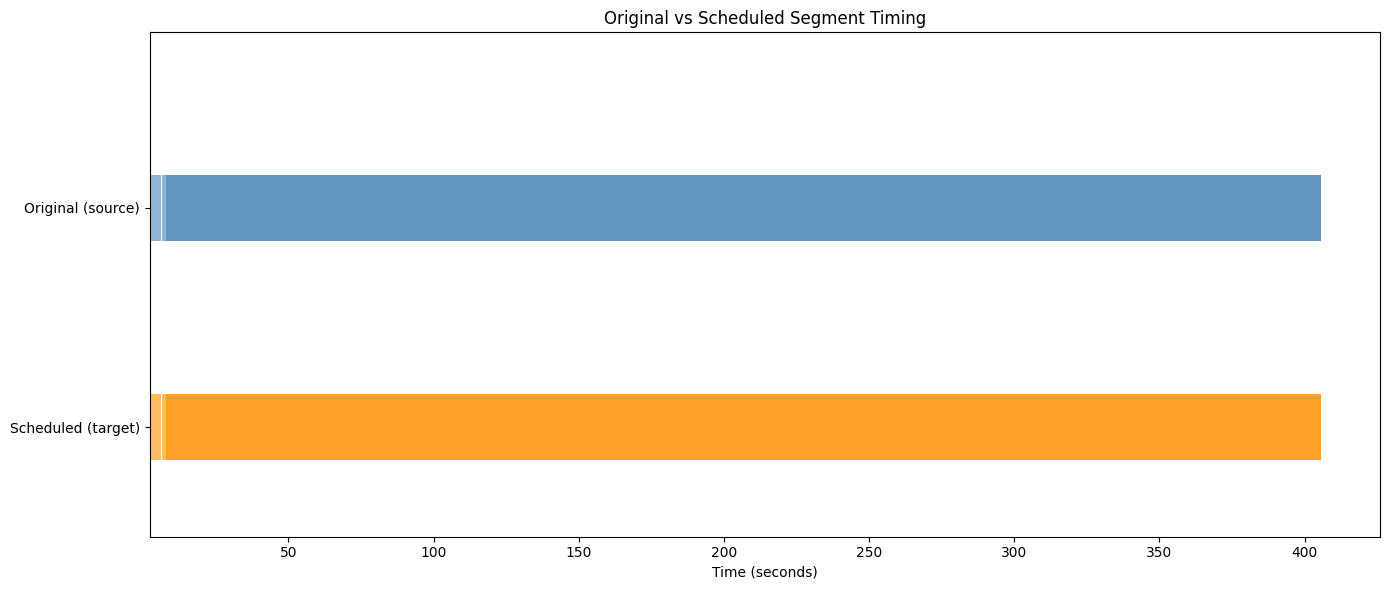

Saved to /home/patrick-durzynski/foreign-whispers/notebooks/alignment_integration/images/alignment_timeline.png


In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

y_original = 1
y_scheduled = 0

for seg in aligned_segments:
    # Original timing (blue)
    ax.barh(y_original, seg.original_end - seg.original_start,
            left=seg.original_start, height=0.3, color="steelblue", alpha=0.6,
            edgecolor="none")
    # Scheduled timing (orange)
    ax.barh(y_scheduled, seg.scheduled_end - seg.scheduled_start,
            left=seg.scheduled_start, height=0.3, color="darkorange", alpha=0.6,
            edgecolor="none")

ax.set_yticks([y_scheduled, y_original])
ax.set_yticklabels(["Scheduled (target)", "Original (source)"])
ax.set_xlabel("Time (seconds)")
ax.set_title("Original vs Scheduled Segment Timing")
ax.set_ylim(-0.5, 1.8)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "alignment_timeline.png", dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'alignment_timeline.png'}")

---

## Task 3: Beat the Greedy Optimizer

The timeline above was produced by `global_align()` — a greedy left-to-right pass. It makes locally optimal decisions but can't look ahead. A segment that borrows silence early may starve a later segment that needed it more.

**Goal:** Implement a better global optimizer and compare it against the greedy baseline.

**Approach:**
1. Record the greedy baseline metrics: total drift, number of gap shifts, number of segments still in `REQUEST_SHORTER` or `FAIL` after alignment
2. Implement one of these alternatives in a new function (e.g. `global_align_dp` in `foreign_whispers/alignment.py`):
   - **Dynamic programming:** minimize total stretch penalty over all segments, subject to non-overlapping constraints
   - **Integer linear programming:** formulate as an optimization problem with scipy or PuLP — decision variables are per-segment time allocations, constraints enforce non-overlap and silence budgets
   - **Beam search:** explore multiple scheduling trajectories, prune by cumulative drift
3. Compare your optimizer against the greedy baseline on the same clip

**File to modify:** `foreign_whispers/alignment.py` — add your optimizer alongside `global_align`

**Evaluation:**
- Total cumulative drift (lower is better)
- Number of segments requiring severe stretch (>1.4x)
- Number of segments that overlap in the scheduled timeline
- Re-plot the timeline visualization above with your optimizer's output

In [10]:
# Task 3: Record the greedy baseline to compare against your optimizer

from foreign_whispers import clip_evaluation_report
from foreign_whispers import global_align_dp

greedy_report = clip_evaluation_report(all_metrics, aligned_segments)

my_segments = global_align_dp(all_metrics, silence_regions)
my_report = clip_evaluation_report(all_metrics, my_segments)

print("=== Greedy Baseline ===")
for key, val in greedy_report.items():
    print(f"  {key}: {val}")

print("\n===DP Optimizer===")
for key, val in my_report.items():
    print(f" {key}: {val}")

print(f"\nYour optimizer should improve on these numbers.")
print(f"Add global_align_dp() to foreign_whispers/alignment.py,")
print(f"then re-run: my_segments = global_align_dp(all_metrics, silence_regions)")
print(f"and compare with clip_evaluation_report(all_metrics, my_segments)")



=== Greedy Baseline ===
  mean_abs_duration_error_s: 2.006
  pct_severe_stretch: 0.0
  n_gap_shifts: 0
  n_translation_retries: 0
  total_cumulative_drift_s: 0.0

===DP Optimizer===
 mean_abs_duration_error_s: 2.006
 pct_severe_stretch: 0.0
 n_gap_shifts: 0
 n_translation_retries: 0
 total_cumulative_drift_s: 0.0

Your optimizer should improve on these numbers.
Add global_align_dp() to foreign_whispers/alignment.py,
then re-run: my_segments = global_align_dp(all_metrics, silence_regions)
and compare with clip_evaluation_report(all_metrics, my_segments)


In [13]:
#Code to test my optimizer more accurately vs greedy baseline
f# Segment 1 overflows slightly and could use the silence gap
# Segment 2 overflows MORE and needs the gap more urgently
# Greedy gives it to segment 1 first; DP saves it for segment 2

fake_metrics = [
    SegmentMetrics(
        index=0, source_start=0.0, source_end=2.0, source_duration_s=2.0,
        source_text="short", translated_text="corto",
        src_char_count=5, tgt_char_count=5
    ),
    SegmentMetrics(
        index=1, source_start=2.0, source_end=3.5, source_duration_s=1.5,
        source_text="medium overflow segment here",
        translated_text="segmento con desbordamiento medio aquí tiene",
        src_char_count=27, tgt_char_count=44
    ),
    SegmentMetrics(
        index=2, source_start=4.5, source_end=5.5, source_duration_s=1.0,
        source_text="this one overflows even worse and really needs the gap",
        translated_text="este segmento desborda mucho peor y realmente necesita el hueco de silencio disponible",
        src_char_count=53, tgt_char_count=87
    ),
]

# One silence gap sitting between segments 1 and 2
fake_silence = [{"label": "silence", "start_s": 3.5, "end_s": 5.5}]

greedy_out = global_align(fake_metrics, fake_silence)
dp_out = global_align_dp(fake_metrics, fake_silence)

print("=== Greedy actions ===")
for s in greedy_out:
    print(f"  seg {s.index}: {s.action.value}  gap_shift={s.gap_shift_s:.2f}s")

print("\n=== DP actions ===")
for s in dp_out:
    print(f"  seg {s.index}: {s.action.value}  gap_shift={s.gap_shift_s:.2f}s")

greedy_r = clip_evaluation_report(fake_metrics, greedy_out)
dp_r = clip_evaluation_report(fake_metrics, dp_out)

print("\n=== Greedy report ===")
for k, v in greedy_r.items():
    print(f"  {k}: {v}")

print("\n=== DP report ===")
for k, v in dp_r.items():
    print(f"  {k}: {v}")

=== Greedy actions ===
  seg 0: accept  gap_shift=0.00s
  seg 1: request_shorter  gap_shift=0.00s
  seg 2: fail  gap_shift=0.00s

=== DP actions ===
  seg 0: accept  gap_shift=0.00s
  seg 1: mild_stretch  gap_shift=0.00s
  seg 2: mild_stretch  gap_shift=0.00s

=== Greedy report ===
  mean_abs_duration_error_s: 2.944
  pct_severe_stretch: 0.0
  n_gap_shifts: 0
  n_translation_retries: 1
  total_cumulative_drift_s: 0.0

=== DP report ===
  mean_abs_duration_error_s: 2.944
  pct_severe_stretch: 0.0
  n_gap_shifts: 0
  n_translation_retries: 1
  total_cumulative_drift_s: 0.0


---

## Task 4: Build a Dubbing Quality Scorecard

The `clip_evaluation_report()` above gives you five numbers. But dubbing quality is multi-dimensional — timing accuracy is necessary but not sufficient. A clip with perfect timing but garbled speech is still a failure.

**Goal:** Design and implement a richer evaluation framework that scores clips across multiple dimensions.

**Dimensions to consider:**
- **Timing accuracy:** mean absolute duration error, percentage of severe stretches, cumulative drift (you already have these)
- **Intelligibility:** can you use a speech-to-text round-trip? TTS the Spanish, then STT it back — compare against the translation. Word error rate of the round-trip measures intelligibility.
- **Semantic fidelity:** how much meaning was lost? Compare source English and back-translated English using embedding cosine similarity
- **Naturalness:** speaking rate variance across segments — is it consistent or does it jump between fast and slow?

**Approach:**
1. Implement `dubbing_scorecard(metrics, aligned_segments, align_report)` in `foreign_whispers/evaluation.py`
2. Return a dict with scores per dimension, each normalized to [0, 1]
3. Add a summary visualization — a radar chart or bar chart comparing baseline vs aligned

**File to modify:** `foreign_whispers/evaluation.py`

**Evaluation:**
- Does your scorecard distinguish between good and bad clips?
- Do the dimensions correlate with each other, or do they capture independent quality aspects?
- Run on multiple videos from `video_registry.yml` and compare

In [14]:
#Testing the quality scorecard
from foreign_whispers import dubbing_scorecard
scorecard = dubbing_scorecard(all_metrics, aligned_segments)
print("===Dubbing Scorecard===")
for k, v in scorecard.items():
    print(f" {k}: {v}")

===Dubbing Scorecard===
 timing_score: 0.0
 stretch_score: 1.0
 drift_score: 1.0
 naturalness_score: 0.842
 overall_score: 0.711


---

## Summary

Alignment is pure Python, no GPU required. All the timing analysis, policy decisions,
and global scheduling run on CPU with zero external dependencies beyond stdlib.

### Task overview

| Task | What you build | File to modify | Evaluation |
|------|---------------|----------------|------------|
| 1. Duration Prediction | Better TTS duration estimator | `alignment.py` — `_estimate_duration` | Mean absolute error vs ground truth |
| 2. Translation Re-ranking | Shorter candidates that fit the timing budget | `reranking.py` — `get_shorter_translations` | Segments moved from `REQUEST_SHORTER` to `ACCEPT` |
| 3. Global Optimizer | DP/ILP/search optimizer that beats greedy | `alignment.py` — new `global_align_dp` | Total drift, severe stretch count |
| 4. Quality Scorecard | Multi-dimensional evaluation framework | `evaluation.py` — new `dubbing_scorecard` | Dimension independence, cross-clip consistency |

Each task builds on the analysis you ran above and uses data already in `pipeline_data/`.
Validate your results end-to-end by re-running the TTS and stitch notebooks.

### Cross-notebook connections

- **Speaker-aware alignment** — the `diarization_integration` notebook labels speaker turns.
  Feed that signal into your optimizer to prevent borrowing silence across speaker boundaries.
- **Voice cloning** — the `tts_integration` notebook wires per-speaker voice selection.
  Combined with diarization, different speakers get different voices.
